# Delayed vs No Delayed analysis

## Imports

In [1]:
from matplotlib import pyplot as plt
import openmc
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Any

import scienceplots
plt.style.use(['science', 'notebook', 'grid', 'high-vis'])  # 'high-vis' 'grid' 'notebook' 'science' 'bright'

## Loading the data

In [2]:
data_delayed: Any = openmc.read_collision_track_file(
    "../data/simple_collision_track/collision_track.h5"
)
data_no_delayed: Any = openmc.read_collision_track_file(
    "../data/simple_collision_track_no_delayed/collision_track.h5"
)


def create_df(data: Any) -> pd.DataFrame:

    df = pd.DataFrame(
        {
            "r_x": data["r"]["x"],
            "r_y": data["r"]["y"],
            "r_z": data["r"]["z"],
            "u_x": data["u"]["x"],
            "u_y": data["u"]["y"],
            "u_z": data["u"]["z"],
            "E": data["E"],
            "dE": data["dE"],
            "time": data["time"],
            "wgt": data["wgt"],
            "event_mt": data["event_mt"],
            "delayed_group": data["delayed_group"],
            "cell_id": data["cell_id"],
            "nuclide_id": data["nuclide_id"],
            "material_id": data["material_id"],
            "universe_id": data["universe_id"],
            "n_collision": data["n_collision"],
            "particle": data["particle"],
            "parent_id": data["parent_id"],
            "progeny_id": data["progeny_id"],
        }
    )
    return df

df_delayed = create_df(data_delayed)
df_no_delayed = create_df(data_no_delayed)
df_delayed.head()

,r_x,r_y,r_z,u_x,u_y,u_z,E,dE,time,wgt,event_mt,delayed_group,cell_id,nuclide_id,material_id,universe_id,n_collision,particle,parent_id,progeny_id
0,1.445122,25.600665,-1.885959,-0.241573,0.970014,-0.026731,1.653544e-02,0.0,0.000723,0.0,101,0,2,50100,2,1,74,0,950001,58
1,-4.262775,27.826917,0.842333,-0.322045,0.939373,-0.117755,1.698394e+06,0.0,8.682390,0.0,101,0,2,50100,2,1,2,0,900007,256
2,-0.894233,26.873307,3.797827,0.110643,0.993507,0.026477,1.285053e-01,0.0,0.002444,0.0,101,0,2,50100,2,1,18,0,950001,607
3,-0.592728,26.600590,1.773482,0.190329,0.868142,-0.458371,1.703333e+06,0.0,0.002312,0.0,101,0,2,50100,2,1,2,0,950001,616
4,1.404506,27.765325,-4.095837,-0.477992,0.863144,0.162806,1.713403e+06,0.0,0.000161,0.0,101,0,2,50100,2,1,1,0,50005,35


## Time distribution comparison

In [6]:
times_delayed = df_delayed["time"][df_delayed["cell_id"] == 2].values
times_no_delayed = df_no_delayed["time"][df_no_delayed["cell_id"] == 2].values

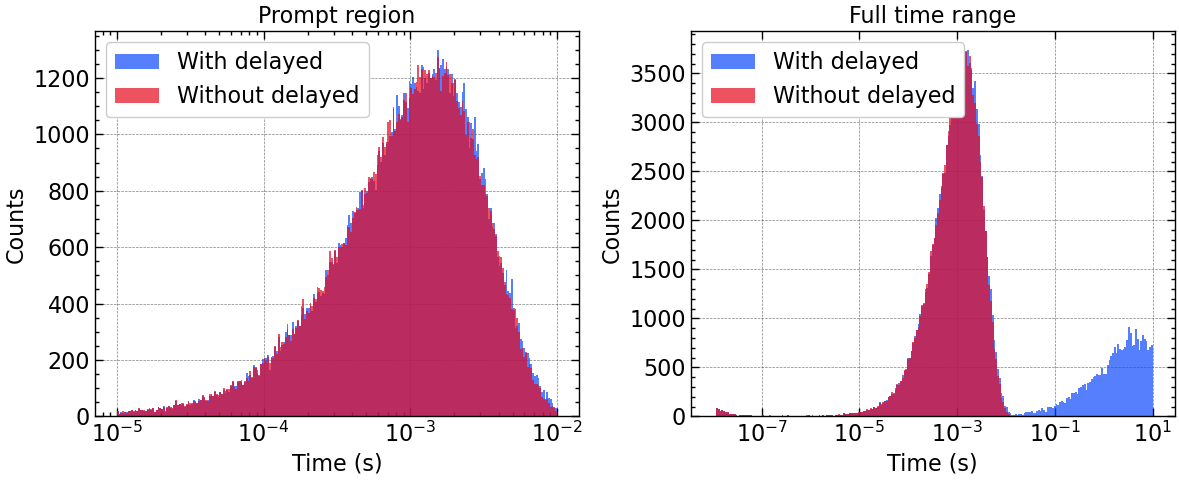

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale - see the prompt peak shape
ax = axes[0]
bins = np.logspace(-5, -2, 250)  # prompt timescale
ax.hist(times_delayed, bins=bins, alpha=0.7, label='With delayed')
ax.hist(times_no_delayed, bins=bins, alpha=0.7, label='Without delayed')
ax.set_xscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Counts')
ax.set_title('Prompt region')
ax.legend()

# Log scale - see the full time range
ax = axes[1]
bins = np.logspace(-8, 1, 250)
ax.hist(times_delayed, bins=bins, alpha=0.7, label='With delayed')
ax.hist(times_no_delayed, bins=bins, alpha=0.7, label='Without delayed')
ax.set_xscale('log')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Counts')
ax.set_title('Full time range')
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/delayed_vs_no_delayed_time_distribution.png", dpi=300)

## Analyze delayed fraction

In [8]:
def analyze_delayed_fraction(times, prompt_cutoff=1e-2):
    """
    Analyze the delayed vs prompt neutron detection fractions.

    Parameters
    ----------
    times : array-like
        Detection times in seconds
    prompt_cutoff : float
        Time threshold separating prompt from delayed (default 10 ms)

    Returns
    -------
    dict with analysis results
    """
    times = np.array(times)

    n_total = len(times)
    n_prompt = np.sum(times < prompt_cutoff)
    n_delayed = np.sum(times >= prompt_cutoff)

    results = {
        "total": n_total,
        "prompt": n_prompt,
        "delayed": n_delayed,
        "delayed_fraction_of_total": n_delayed / n_total if n_total > 0 else 0,
        "delayed_to_prompt_ratio": n_delayed / n_prompt if n_prompt > 0 else 0,
        "prompt_cutoff": prompt_cutoff,
    }

    return results


results = analyze_delayed_fraction(times_delayed, prompt_cutoff=1e-2)

print(f"Prompt cutoff: {results['prompt_cutoff']*1000:.1f} ms")
print(f"Total detections: {results['total']}")
print(f"Prompt (< cutoff): {results['prompt']}")
print(f"Delayed (≥ cutoff): {results['delayed']}")
print(f"Delayed / Total: {results['delayed_fraction_of_total']*100:.1f}%")
print(f"Delayed / Prompt: {results['delayed_to_prompt_ratio']*100:.1f}%")

Prompt cutoff: 10.0 ms
Total detections: 160858
Prompt (< cutoff): 119101
Delayed (≥ cutoff): 41757
Delayed / Total: 26.0%
Delayed / Prompt: 35.1%


In [22]:
results_no_delayed = analyze_delayed_fraction(times_no_delayed, prompt_cutoff=1e-2)
print(f"'Delayed' in no-delayed run: {results_no_delayed['delayed_fraction_of_total']*100:.1f}%")

'Delayed' in no-delayed run: 0.1%


In [23]:
beta = 0.0065  # delayed fraction per fission
k = 0.98
M = 1 / (1 - k)  # ~50

# Rough estimate: delayed neutrons also multiply
effective_delayed_fraction = beta * M / (1 + beta * M)
print(f"Rough estimate: {effective_delayed_fraction*100:.1f}%")

Rough estimate: 24.5%
